In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

$Multisyllabic_{observed} = f_1(objective) + f_2(cognitive)$

В наших данных нет признаков, которые бы отвечали за когнитивные способности, поэтому при построении модели, мы находим только часть отвечающую за объективные слуховые показатели пациента:

$Multisyllabic_{predict} = f_1(objective)$

Тогда наша ошибка/смещение предсказания это и будет когнитивная составляющая:

$error = Multisyllabic_{observed} - Multisyllabic_{predict} = f_2(cognitive)$


$Monosyllabic_{observed} = f_1(objective)$

- 53 ненулевых по Monosyllabic
- 17 ненулевых по Multisyllabic

In [83]:
df = pd.read_csv('../data/result.csv')

In [169]:
df.columns

Index(['Factor', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 250Hz AC', 'PTA left 500Hz AC',
       'PTA left 1000Hz AC', 'PTA left 2000Hz AC', 'PTA left 4000Hz AC',
       'PTA left 8000Hz AC', 'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Multisyllabic speech without HA in quiet FF, %',
       'Multisyllabic speech with HA in quiet FF, %',
       'Multisyllabic speech without HA in babble noise FF, %',
       'Multisyllabic speech with HA in white noise FF, %',
       'Multisyllabic speech with HA in babble noise FF, %',
       'Monosyllabic speech HA in quiet FF, %',
       'Monosyllabic speech HA in white noise FF, %',
       'Patient's rating about HA effeciency : 1 - very bad; 5 excellent',
       'Predicted Multisyllabic speech without HA in quiet FF, %',
       'Predicted Multisyllabic speech with HA in qui

In [123]:
columns_select = ['Multisyllabic speech without HA in quiet FF, %', 
                  'Multisyllabic speech with HA in quiet FF, %', 
                 'Predicted Multisyllabic speech without HA in quiet FF, %', 
                  'Predicted Multisyllabic speech with HA in quiet FF, %'
                 ]

In [124]:
# columns_select = ['Multisyllabic speech with HA in quiet FF, %', 
#                   'Monosyllabic speech HA in quiet FF, %',
#                   'Predicted Multisyllabic speech with HA in quiet FF, %', 
#                   'Predicted Monosyllabic speech HA in quiet FF, %'
#                  ]

In [125]:
k = df[columns_select]

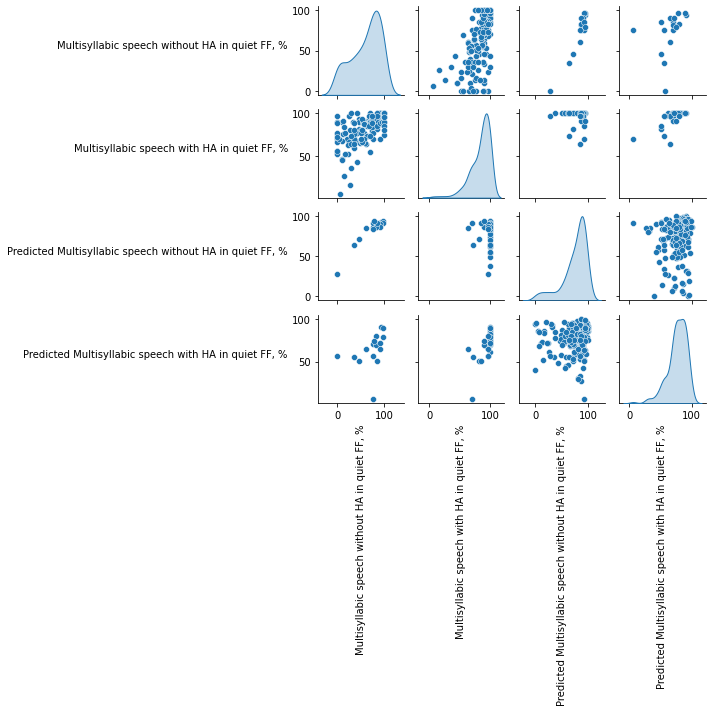

In [126]:
g = sns.pairplot(k, diag_kind="kde")
# g.map_lower(sns.kdeplot, levels=4, color=".2")

for ax in g.axes.flatten():
    # rotate x axis labels
    ax.set_xlabel(ax.get_xlabel(), rotation = 90)
    # rotate y axis labels
    ax.set_ylabel(ax.get_ylabel(), rotation = 0)
    # set y labels alignment
    ax.yaxis.get_label().set_horizontalalignment('right')
plt.tight_layout()
plt.savefig('../figure/HA_all.svg', format='svg', dpi=1200)

In [157]:
# p1 = 'Predicted Multisyllabic speech with HA in quiet FF, %'
# p2 = 'Predicted Monosyllabic speech HA in quiet FF, %'
# k1 = 'Multisyllabic speech with HA in quiet FF, %'
# k2 = 'Monosyllabic speech HA in quiet FF, %'

# p1 = 'Predicted Multisyllabic speech with HA in quiet FF, %'
# p2 = 'Predicted Monosyllabic speech HA in quiet FF, %'
# k1 = 'Multisyllabic speech with HA in quiet FF, %'
# k2 = 'Monosyllabic speech HA in quiet FF, %'

k1 = 'Multisyllabic speech without HA in quiet FF, %' 
k2 = 'Multisyllabic speech with HA in quiet FF, %'
p1 = 'Predicted Multisyllabic speech without HA in quiet FF, %' 
p2 = 'Predicted Multisyllabic speech with HA in quiet FF, %'

In [158]:
cols = [k1, k2, p1, p2]

In [159]:
# color_dict = {k1: 'tab:blue', k2: 'tab:orange', p1: 'tab:cyan', p2: 'tab:brown'}

In [164]:
# cols = [k1, p1]
# color_dict = {k1: 'tab:blue', p1: 'tab:orange'}

cols = [k2, p2]
color_dict = {k2: 'tab:blue', p2: 'tab:orange'}

In [165]:
# df.dropna(subset=['Multisyllabic speech without HA in quiet FF, %', 
#                    'Predicted Multisyllabic speech without HA in quiet FF, %'])

In [166]:
# df.dropna(subset=['Monosyllabic speech HA in quiet FF, %', 
#                    'Predicted Monosyllabic speech HA in quiet FF, %'])

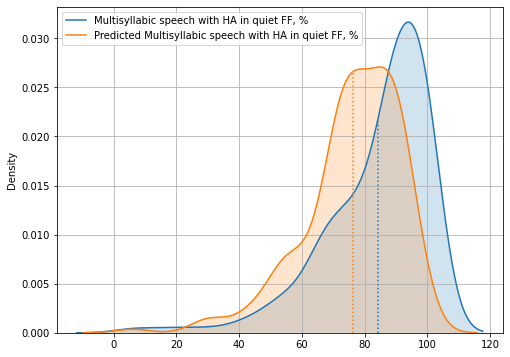

In [167]:
fig, ax = plt.subplots(figsize=(8, 6))

for num, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, label=col, ax=ax, color=color_dict[col])
#     ax.set(title=f'Distribution of Column: {col}', xlabel=None)

    kdeline = ax.lines[num]
    mean = df[col].mean()
    xs = kdeline.get_xdata()
    ys = kdeline.get_ydata()
    height = np.interp(mean, xs, ys)
    ax.vlines(mean, 0, height, color=color_dict[col], ls=':')
    ax.fill_between(xs, 0, ys, facecolor=color_dict[col], alpha=0.2)
# fig.delaxes(axes[5])  # delete the empty subplot
# fig.tight_layout()
plt.legend()
plt.grid()
plt.xlabel('')

plt.savefig('../figure/HA_with_obs_pred_multi.svg', format='svg', dpi=1200)

## Find error

In [33]:
column_name1 = 'Multisyllabic speech with HA in quiet FF, %'
column_name2 = 'Monosyllabic speech HA in quiet FF, %'

In [34]:
df['Error ' + column_name1] = df[column_name1] - df['Predicted ' + column_name1]
df['Error ' + column_name2] = df[column_name2] - df['Predicted ' + column_name2]

In [35]:
k = df[column_name1] - df['Predicted ' + column_name1]

In [36]:
k

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
489   NaN
490   NaN
491   NaN
492   NaN
493   NaN
Length: 494, dtype: float64

In [37]:
def plot_hist(df, cols, figure_name='error.svg'):
    color_list =  ['tab:blue','tab:orange']
    fig, ax = plt.subplots(figsize=(8, 6))

    for num, col in enumerate(cols):
        sns.histplot(data=df, x=col, label=col, ax=ax, kde = True,
             line_kws = {'linestyle':'dashed',
                         'linewidth':'2'}, color=color_list[num])

    plt.legend()
    plt.grid()
    plt.xlabel('')
    plt.savefig(figure_name, format='svg', dpi=1200)

In [38]:
def plot_kde(df, cols, figure_name='error.svg'):
    color_list =  ['tab:blue','tab:orange']
    fig, ax = plt.subplots(figsize=(8, 6))

    for num, col in enumerate(cols):
#         sns.histplot(data=df, x=col, label=col, ax=ax, kde_kws = {'bw_adjust': 0.5}, color=color_list[num])
        sns.kdeplot(data=df, x=col, label=col, ax=ax)

        kdeline = ax.lines[num]
        mean = df[col].mean()
        xs = kdeline.get_xdata()
        ys = kdeline.get_ydata()
        height = np.interp(mean, xs, ys)
        ax.vlines(mean, 0, height, color=color_list[num], ls=':')
        ax.fill_between(xs, 0, ys, facecolor=color_list[num], alpha=0.2)

    plt.legend()
    plt.grid()
    plt.xlabel('')
    plt.savefig(figure_name, format='svg', dpi=1200)

In [39]:
col = ['Error ' + column_name1, 'Error ' + column_name2]

In [40]:
df

,Factor,PTA right 250Hz AC,PTA right 500Hz AC,PTA right 1000Hz AC,PTA right 2000Hz AC,PTA right 4000Hz AC,PTA right 8000Hz AC,PTA left 250Hz AC,PTA left 500Hz AC,PTA left 1000Hz AC,...,"Predicted Multisyllabic speech without HA in quiet FF, %","Predicted Multisyllabic speech with HA in quiet FF, %","Predicted Multisyllabic speech without HA in babble noise FF, %","Predicted Multisyllabic speech with HA in white noise FF, %","Predicted Multisyllabic speech with HA in babble noise FF, %","Predicted Monosyllabic speech HA in quiet FF, %","Predicted Monosyllabic speech HA in white noise FF, %",Predicted Patient's rating about HA effeciency : 1 - very bad; 5 excellent,"Error Multisyllabic speech with HA in quiet FF, %","Error Monosyllabic speech HA in quiet FF, %"
0,1,NaN,35.0,40.0,55.0,70.0,NaN,NaN,30.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,NaN,120.0,120.0,120.0,120.0,NaN,NaN,75.0,100.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,NaN,40.0,50.0,50.0,70.0,NaN,NaN,35.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,NaN,50.0,50.0,50.0,60.0,NaN,NaN,55.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,NaN,30.0,45.0,45.0,45.0,NaN,NaN,50.0,40.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
489,490,30.0,50.0,55.0,40.0,40.0,65.0,35.0,45.0,50.0,...,63.291308,74.840289,28.665198,98.084621,65.235701,66.709180,97.950034,4.399300,NaN,NaN
490,491,30.0,35.0,35.0,55.0,65.0,80.0,90.0,90.0,75.0,...,79.445897,64.615238,59.690465,81.969345,61.653326,58.399263,57.250224,4.655810,NaN,NaN
491,492,50.0,50.0,55.0,50.0,45.0,50.0,50.0,50.0,60.0,...,91.575008,63.030851,77.558454,87.081978,79.716748,65.282277,74.975782,4.222921,NaN,NaN
492,493,45.0,40.0,50.0,50.0,40.0,35.0,45.0,40.0,45.0,...,71.649241,53.384599,50.580887,96.200119,48.845130,56.821197,90.165159,4.098432,NaN,NaN


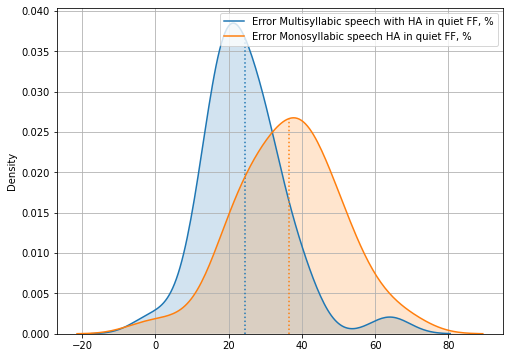

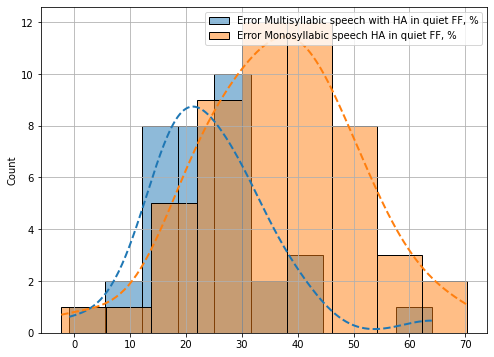

In [41]:
plot_kde(df, col, figure_name='../figure/error_mono_multi_HA.svg')
plot_hist(df, col, figure_name='../figure/error_mono_multi_HA_h.svg')

Если установим multisyllabic speech в ноль, то получается, что наша модель завышает значения. 

## Слуховой аппарат

In [43]:
column_name1 = 'Multisyllabic speech without HA in quiet FF, %'
column_name2 = 'Multisyllabic speech with HA in quiet FF, %'

In [44]:
df['Error ' + column_name1] = df[column_name1] - df['Predicted ' + column_name1]
df['Error ' + column_name2] = df[column_name2] - df['Predicted ' + column_name2]

In [45]:
col = ['Error ' + column_name1, 'Error ' + column_name2]

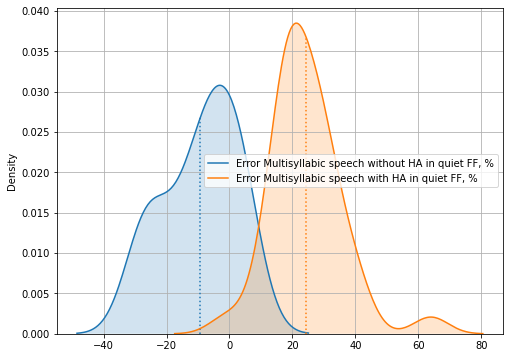

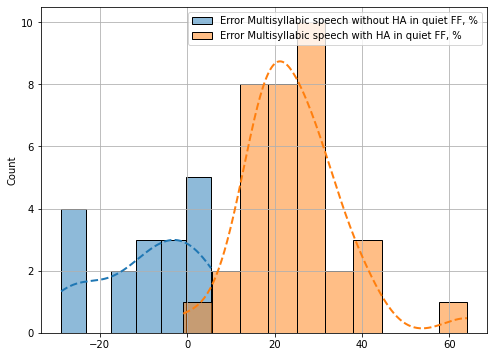

In [46]:
plot_kde(df, col, figure_name='../figure/error_multi_HA.svg')
plot_hist(df, col, figure_name='../figure/error_multi_HA_h.svg')

In [ ]:
col = ['Error ' + column_name1, 'Error ' + column_name2]

plot_kde(df, col, figure_name='../figure/error_mono_multi_HA.svg')
plot_hist(df, col, figure_name='../figure/error_mono_multi_HA_h.svg')

## Анализ шума

In [ ]:
columns_select = ['Predicted Multisyllabic speech with HA in quiet FF, %',
                  'Predicted Multisyllabic speech without HA in babble noise FF, %',
                  'Predicted Multisyllabic speech with HA in white noise FF, %',
                  'Predicted Multisyllabic speech with HA in babble noise FF, %']

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

for num, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, label=col, ax=ax, color=color_dict[col])

    kdeline = ax.lines[num]
    mean = df[col].mean()
    xs = kdeline.get_xdata()
    ys = kdeline.get_ydata()
    height = np.interp(mean, xs, ys)
    ax.vlines(mean, 0, height, color=color_dict[col], ls=':')
    ax.fill_between(xs, 0, ys, facecolor=color_dict[col], alpha=0.2)

plt.legend()
plt.grid()
plt.xlabel('')

In [189]:
p1 = 'Multisyllabic speech without HA in quiet FF, %'
p2 = 'Multisyllabic speech without HA in babble noise FF, %'
k1 = 'Predicted Multisyllabic speech without HA in quiet FF, %'
k2 = 'Predicted Multisyllabic speech without HA in babble noise FF, %'

In [190]:
cols = [k1, k2, p1, p2]

In [191]:
color_dict = {k1: 'tab:blue', k2: 'tab:orange', p1: 'tab:cyan', p2: 'tab:brown'}


In [192]:
# cols = [k1, p1]
# color_dict = {k1: 'tab:blue', p1: 'tab:orange'}

cols = [k2, p2]
color_dict = {k2: 'tab:blue', p2: 'tab:orange'}

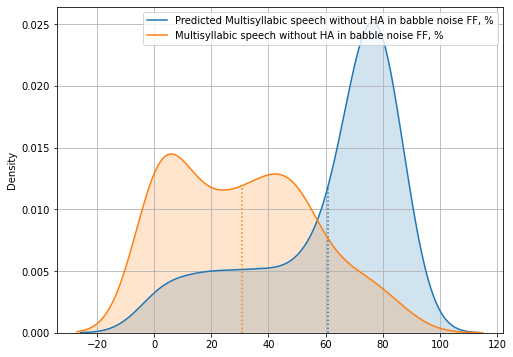

In [193]:
fig, ax = plt.subplots(figsize=(8, 6))

for num, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, label=col, ax=ax, color=color_dict[col])
#     ax.set(title=f'Distribution of Column: {col}', xlabel=None)

    kdeline = ax.lines[num]
    mean = df[col].mean()
    xs = kdeline.get_xdata()
    ys = kdeline.get_ydata()
    height = np.interp(mean, xs, ys)
    ax.vlines(mean, 0, height, color=color_dict[col], ls=':')
    ax.fill_between(xs, 0, ys, facecolor=color_dict[col], alpha=0.2)
# fig.delaxes(axes[5])  # delete the empty subplot
# fig.tight_layout()
plt.legend()
plt.grid()
plt.xlabel('')

plt.savefig('../figure/noise_obs_pred_multi_.svg', format='svg', dpi=1200)

In [195]:
p1 = 'Multisyllabic speech with HA in quiet FF, %'
p2 = 'Multisyllabic speech with HA in babble noise FF, %'
k1 = 'Predicted Multisyllabic speech with HA in quiet FF, %'
k2 = 'Predicted Multisyllabic speech with HA in babble noise FF, %'

In [194]:
df.columns

Index(['Factor', 'PTA right 250Hz AC', 'PTA right 500Hz AC',
       'PTA right 1000Hz AC', 'PTA right 2000Hz AC', 'PTA right 4000Hz AC',
       'PTA right 8000Hz AC', 'PTA left 250Hz AC', 'PTA left 500Hz AC',
       'PTA left 1000Hz AC', 'PTA left 2000Hz AC', 'PTA left 4000Hz AC',
       'PTA left 8000Hz AC', 'Right HL degree: 0=no HL; 1-4; 5=deafness',
       'Left HL degree: 0=no HL; 1-4; 5=deafness',
       'Multisyllabic speech without HA in quiet FF, %',
       'Multisyllabic speech with HA in quiet FF, %',
       'Multisyllabic speech without HA in babble noise FF, %',
       'Multisyllabic speech with HA in white noise FF, %',
       'Multisyllabic speech with HA in babble noise FF, %',
       'Monosyllabic speech HA in quiet FF, %',
       'Monosyllabic speech HA in white noise FF, %',
       'Patient's rating about HA effeciency : 1 - very bad; 5 excellent',
       'Predicted Multisyllabic speech without HA in quiet FF, %',
       'Predicted Multisyllabic speech with HA in qui

In [202]:
cols = [k1, k2, p1, p2]

In [203]:
# color_dict = {k1: 'tab:blue', k2: 'tab:orange', p1: 'tab:cyan', p2: 'tab:brown'}


In [204]:
# cols = [k1, p1]
# color_dict = {k1: 'tab:blue', p1: 'tab:orange'}

cols = [k2, p2]
color_dict = {k2: 'tab:blue', p2: 'tab:orange'}

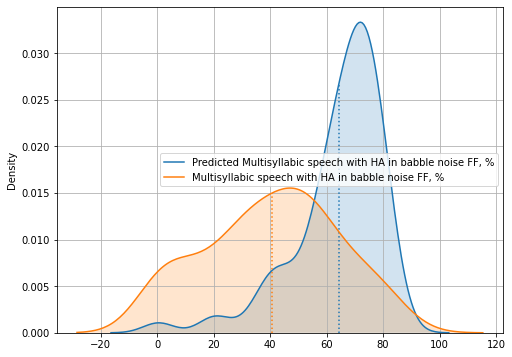

In [205]:
fig, ax = plt.subplots(figsize=(8, 6))

for num, col in enumerate(cols):
    sns.kdeplot(data=df, x=col, label=col, ax=ax, color=color_dict[col])
#     ax.set(title=f'Distribution of Column: {col}', xlabel=None)

    kdeline = ax.lines[num]
    mean = df[col].mean()
    xs = kdeline.get_xdata()
    ys = kdeline.get_ydata()
    height = np.interp(mean, xs, ys)
    ax.vlines(mean, 0, height, color=color_dict[col], ls=':')
    ax.fill_between(xs, 0, ys, facecolor=color_dict[col], alpha=0.2)
# fig.delaxes(axes[5])  # delete the empty subplot
# fig.tight_layout()
plt.legend()
plt.grid()
plt.xlabel('')

plt.savefig('../figure/noiseHA_obs_pred_multi.svg', format='svg', dpi=1200)